# **Import & Data Understanding**

Tahap ini memuat library dan dataset, lalu mengecek kualitas dan struktur data.

- Mengimpor library data, visualisasi, dan model
- Memuat `dataset.csv` dan menampilkan sampel data
- Mengecek tipe data, jumlah nilai unik, nilai kosong, dan duplikat
- Menampilkan statistik deskriptif dan memisahkan kolom numerik dan kategorikal

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle as pkl
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, root_mean_squared_error, mean_squared_error, mean_absolute_percentage_error

In [ ]:
df = pd.read_csv("data/table/dataset.csv")
df.head()

,system:index,B11,B12,B2,B3,B4,B5,B6,B8,DVI,...,flooded_vegetation,grass,grid_id,shrub_and_scrub,slope,snow_and_ice,trees,water,year_month,.geo
0,00000000000000000000,1494.0,599.0,0.0223,0.0409,0.0196,720.0,2664.0,0.3284,0.3088,...,0.029714,0.035282,"1146,-6",0.041272,0,0.031044,0.739627,0.031752,2024-06,"{""type"":""Point"",""coordinates"":[102.95982284947..."
1,00000000000000000001,1526.0,598.0,0.0231,0.0400,0.0209,706.0,2853.0,0.3784,0.3575,...,0.027693,0.032041,"1146,-6",0.028255,0,0.035552,0.747575,0.034439,2024-06,"{""type"":""Point"",""coordinates"":[102.95901575218..."
2,00000000000000000002,1619.0,693.0,0.0232,0.0433,0.0206,683.0,2444.0,0.3460,0.3254,...,0.040364,0.104834,"1146,-4",0.061151,0,0.034415,0.466250,0.031786,2024-06,"{""type"":""Point"",""coordinates"":[103.01749240339..."
3,00000000000000000003,2006.0,811.0,0.0247,0.0650,0.0224,1225.0,4360.0,0.4928,0.4704,...,0.032922,0.132219,"1146,-4",0.030930,0,0.038207,0.583990,0.030178,2024-06,"{""type"":""Point"",""coordinates"":[103.01560620365..."
4,00000000000000000004,1709.0,876.0,0.0232,0.0464,0.0257,789.0,2248.0,0.3300,0.3043,...,0.030709,0.092348,"1146,-4",0.079499,0,0.032977,0.401133,0.036386,2024-06,"{""type"":""Point"",""coordinates"":[103.01722485733..."


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3337 entries, 0 to 3336
Data columns (total 40 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   system:index        3337 non-null   str    
 1   B11                 3337 non-null   float64
 2   B12                 3337 non-null   float64
 3   B2                  3337 non-null   float64
 4   B3                  3337 non-null   float64
 5   B4                  3337 non-null   float64
 6   B5                  3337 non-null   float64
 7   B6                  3337 non-null   float64
 8   B8                  3337 non-null   float64
 9   DVI                 3337 non-null   float64
 10  EVI                 3337 non-null   float64
 11  GNDVI               3337 non-null   float64
 12  NDVI                3337 non-null   float64
 13  RVI                 3337 non-null   float64
 14  VH                  3337 non-null   float64
 15  VH_contrast         3337 non-null   float64
 16  VH_corr          

In [4]:
df.nunique()

system:index          3337
B11                   1439
B12                   1060
B2                     487
B3                     673
B4                     561
B5                     935
B6                    1634
B8                    1664
DVI                   1936
EVI                   3285
GNDVI                 3250
NDVI                  3254
RVI                   3247
VH                    3285
VH_contrast           3282
VH_corr               3285
VH_ent                 755
VV                    3284
VV_contrast           3279
VV_corr               3284
VV_ent                 835
agbd                  3245
agbd_se               1969
aspect                 360
bare                  2388
built                 2493
crops                 2490
date                     3
dem                   3280
flooded_vegetation    2420
grass                 2500
grid_id                176
shrub_and_scrub       2695
slope                   48
snow_and_ice          1985
trees                 2325
w

In [5]:
df.isna().sum()

system:index          0
B11                   0
B12                   0
B2                    0
B3                    0
B4                    0
B5                    0
B6                    0
B8                    0
DVI                   0
EVI                   0
GNDVI                 0
NDVI                  0
RVI                   0
VH                    0
VH_contrast           0
VH_corr               0
VH_ent                0
VV                    0
VV_contrast           0
VV_corr               0
VV_ent                0
agbd                  0
agbd_se               0
aspect                0
bare                  0
built                 0
crops                 0
date                  0
dem                   0
flooded_vegetation    0
grass                 0
grid_id               0
shrub_and_scrub       0
slope                 0
snow_and_ice          0
trees                 0
water                 0
year_month            0
.geo                  0
dtype: int64

In [6]:
df[df.duplicated()]

,system:index,B11,B12,B2,B3,B4,B5,B6,B8,DVI,...,flooded_vegetation,grass,grid_id,shrub_and_scrub,slope,snow_and_ice,trees,water,year_month,.geo


In [7]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
B11,3337.0,1549.402008,325.331318,180.000000,1356.000000,1542.500000,1723.000000,3546.000000
B12,3337.0,688.092598,211.723718,81.000000,561.000000,659.000000,773.500000,2406.000000
B2,3337.0,0.022777,0.007704,0.009550,0.018600,0.021400,0.025100,0.127800
B3,3337.0,0.039463,0.011753,0.016100,0.032200,0.037600,0.044250,0.186800
B4,3337.0,0.022666,0.012274,0.007300,0.017000,0.020100,0.024600,0.235800
B5,3337.0,678.842523,172.160316,303.000000,565.000000,651.000000,759.000000,1941.000000
B6,3337.0,2211.104435,412.250538,726.000000,1916.000000,2220.000000,2466.000000,4360.000000
B8,3337.0,0.281591,0.055013,0.089300,0.242200,0.282100,0.316000,0.555600
DVI,3337.0,0.258921,0.055271,-0.048400,0.220200,0.258500,0.293800,0.529600
EVI,3337.0,0.516357,0.091994,-0.078373,0.456092,0.519737,0.575984,0.889277


In [8]:
num_cols = df.select_dtypes(include=np.number).columns
cat_cols = df.select_dtypes(include='str').columns

print(f"Numeric columns: {num_cols}")
print(f"Categorical columns: {cat_cols}")

Numeric columns: Index(['B11', 'B12', 'B2', 'B3', 'B4', 'B5', 'B6', 'B8', 'DVI', 'EVI', 'GNDVI',
       'NDVI', 'RVI', 'VH', 'VH_contrast', 'VH_corr', 'VH_ent', 'VV',
       'VV_contrast', 'VV_corr', 'VV_ent', 'agbd', 'agbd_se', 'aspect', 'bare',
       'built', 'crops', 'dem', 'flooded_vegetation', 'grass',
       'shrub_and_scrub', 'slope', 'snow_and_ice', 'trees', 'water'],
      dtype='str')
Categorical columns: Index(['system:index', 'date', 'grid_id', 'year_month', '.geo'], dtype='str')


# **Data Visualization**

Tahap ini mengeksplorasi pola data dan hubungan antar fitur dengan AGBD melalui visualisasi.

- Histogram sebaran AGBD beserta median dan rata-rata
- Boxplot AGBD per bulan akuisisi
- Scatter plot elevasi (DEM) terhadap AGBD dengan garis tren
- Korelasi Pearson tiap fitur terhadap AGBD
- Rata-rata probabilitas kelas Dynamic World
- Heatmap korelasi antar seluruh fitur dan fitur terhadap AGBD

In [9]:
continuous_cmap = "viridis"
corr_cmap = "RdBu_r"

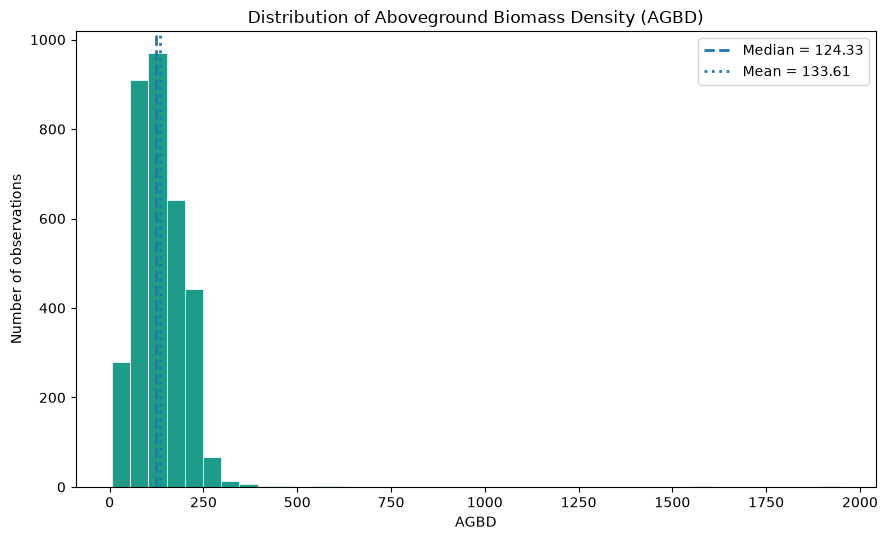

In [10]:
plt.figure(figsize=(9, 5.5))
plt.hist(df["agbd"].dropna(), bins=40, color=plt.get_cmap("viridis")(0.55),
         edgecolor="white", linewidth=0.5)
plt.axvline(df["agbd"].median(), linestyle="--", linewidth=2,
            label=f"Median = {df['agbd'].median():.2f}")
plt.axvline(df["agbd"].mean(), linestyle=":", linewidth=2,
            label=f"Mean = {df['agbd'].mean():.2f}")
plt.xlabel("AGBD")
plt.ylabel("Number of observations")
plt.title("Distribution of Aboveground Biomass Density (AGBD)")
plt.legend()
plt.tight_layout()
plt.show()

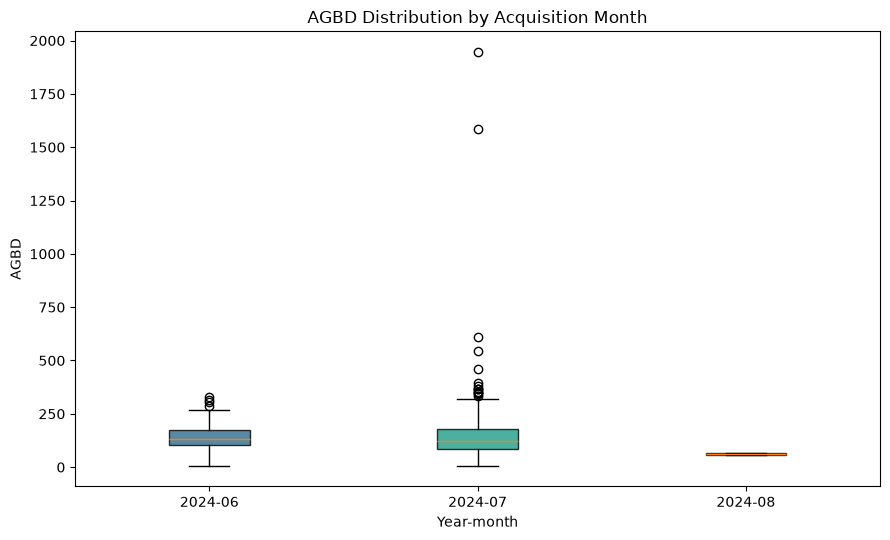

In [11]:
months = sorted(df["year_month"].dropna().unique())
groups = [df.loc[df["year_month"] == m, "agbd"].dropna() for m in months]

plt.figure(figsize=(9, 5.5))
bp = plt.boxplot(groups, patch_artist=True, tick_labels=months,
                 showfliers=True)
for patch, value in zip(bp["boxes"], np.linspace(0.35, 0.75, len(bp["boxes"]))):
    patch.set_facecolor(plt.get_cmap("viridis")(value))
    patch.set_alpha(0.8)
plt.xlabel("Year-month")
plt.ylabel("AGBD")
plt.title("AGBD Distribution by Acquisition Month")
plt.tight_layout()
plt.show()

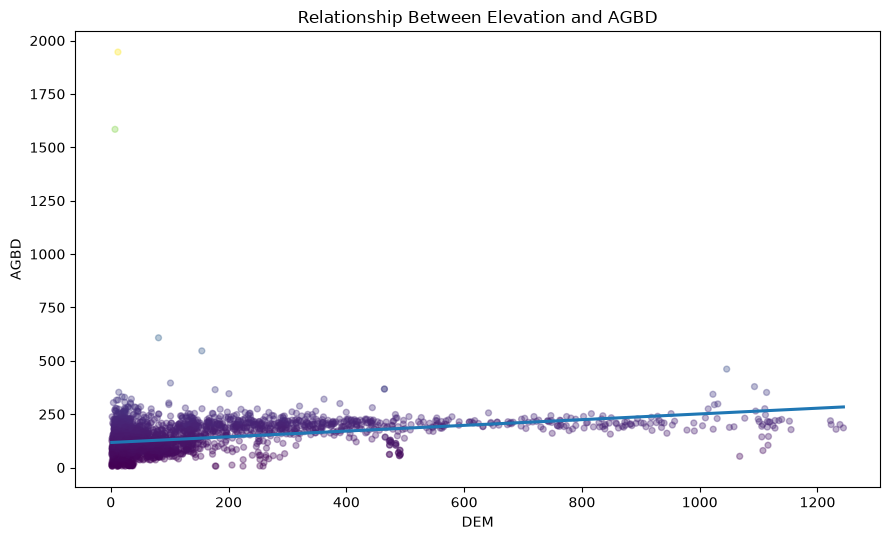

In [12]:
plot_df = df[["dem", "agbd"]].dropna()
plt.figure(figsize=(9, 5.5))
plt.scatter(plot_df["dem"], plot_df["agbd"], s=18, alpha=0.35,
            c=plot_df["agbd"], cmap="viridis")
z = np.polyfit(plot_df["dem"], plot_df["agbd"], 1)
x = np.linspace(plot_df["dem"].min(), plot_df["dem"].max(), 200)
plt.plot(x, z[0] * x + z[1], linewidth=2.2)
plt.xlabel("DEM")
plt.ylabel("AGBD")
plt.title("Relationship Between Elevation and AGBD")
plt.tight_layout()
plt.show()

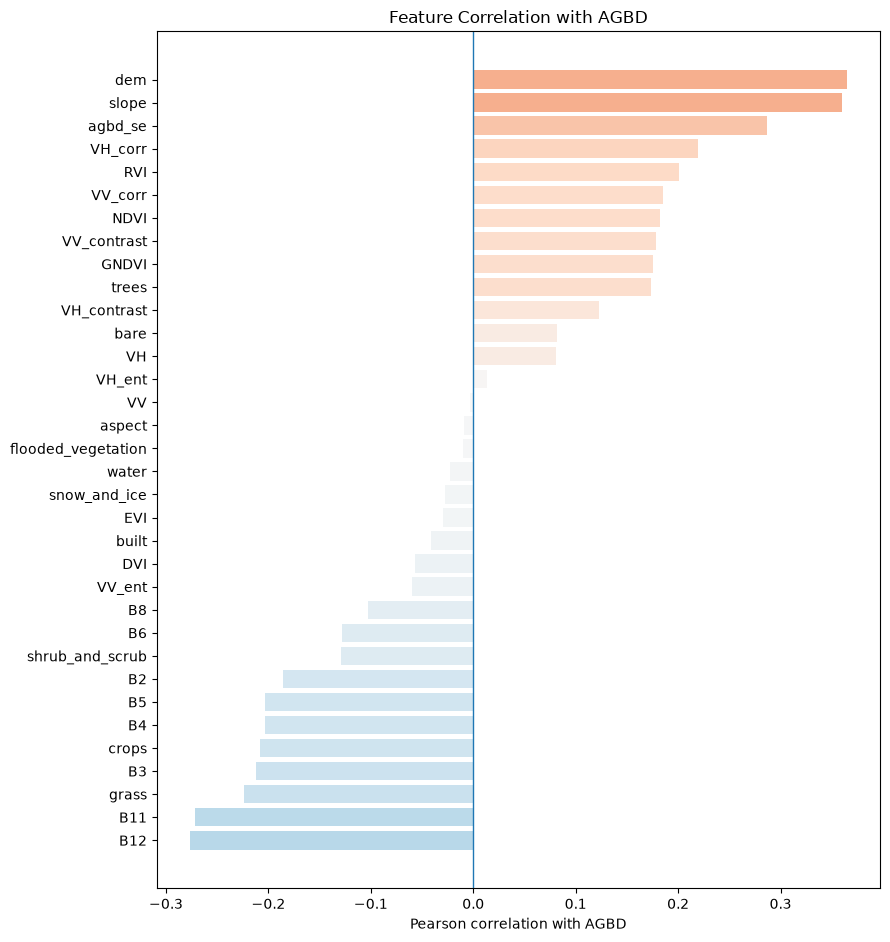

In [13]:
numeric = df.select_dtypes(include=np.number)
corr_agbd = numeric.corr()["agbd"].drop("agbd").sort_values()
plt.figure(figsize=(9, max(5.5, len(corr_agbd) * 0.28)))
colors = plt.get_cmap("RdBu_r")((corr_agbd.values + 1) / 2)
plt.barh(corr_agbd.index, corr_agbd.values, color=colors)
plt.axvline(0, linewidth=1)
plt.xlabel("Pearson correlation with AGBD")
plt.title("Feature Correlation with AGBD")
plt.tight_layout()
plt.show()

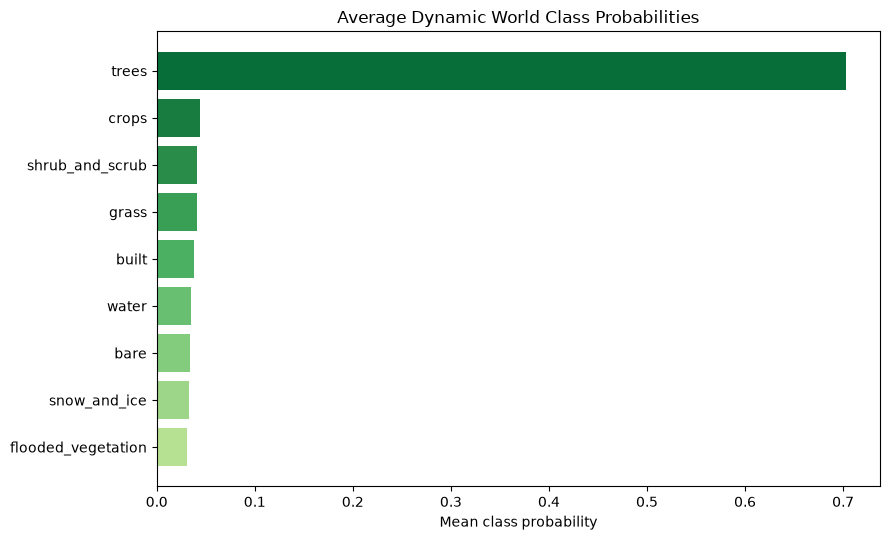

In [14]:
dw_classes = [
    c for c in [
        "trees", "crops", "shrub_and_scrub", "grass", "built",
        "water", "bare", "flooded_vegetation", "snow_and_ice"
    ] if c in df.columns
]
dw_mean = df[dw_classes].mean().sort_values()

plt.figure(figsize=(9, 5.5))
plt.barh(dw_mean.index, dw_mean.values, color=plt.get_cmap("YlGn")(np.linspace(0.35, 0.85, len(dw_mean)))) 
plt.xlabel("Mean class probability")
plt.title("Average Dynamic World Class Probabilities")
plt.tight_layout()
plt.show()

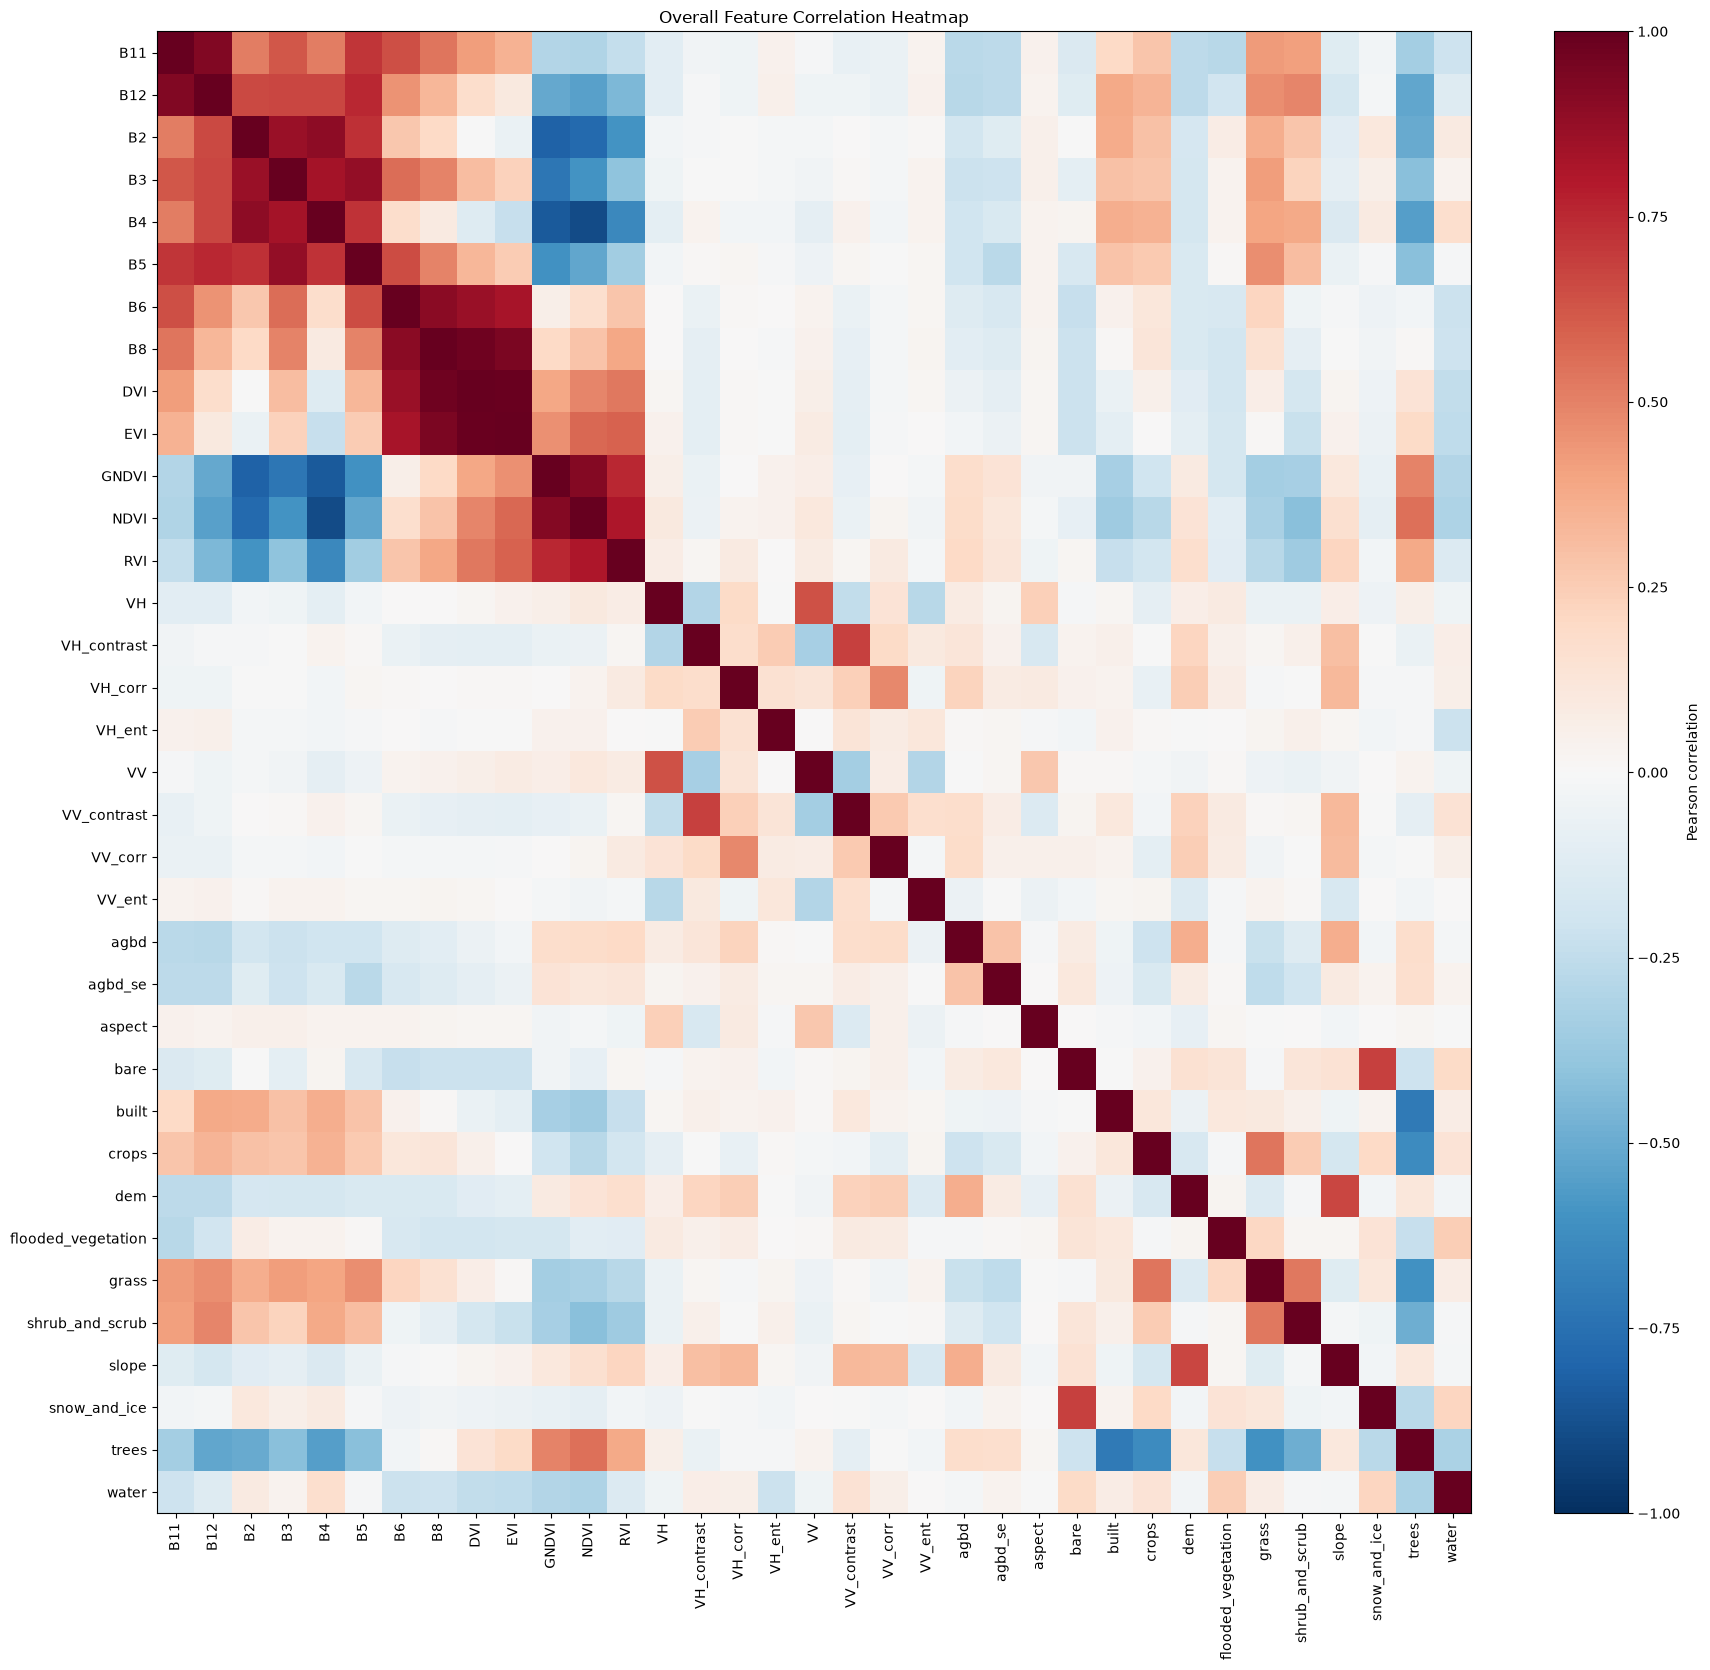

In [15]:
corr = numeric.corr()
fig_w = max(11, len(corr.columns) * 0.52)
fig_h = max(9, len(corr.columns) * 0.48)

plt.figure(figsize=(fig_w, fig_h))
im = plt.imshow(corr, cmap=corr_cmap, vmin=-1, vmax=1, aspect="auto")
plt.colorbar(im, label="Pearson correlation")
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Overall Feature Correlation Heatmap")
plt.tight_layout()
plt.show()

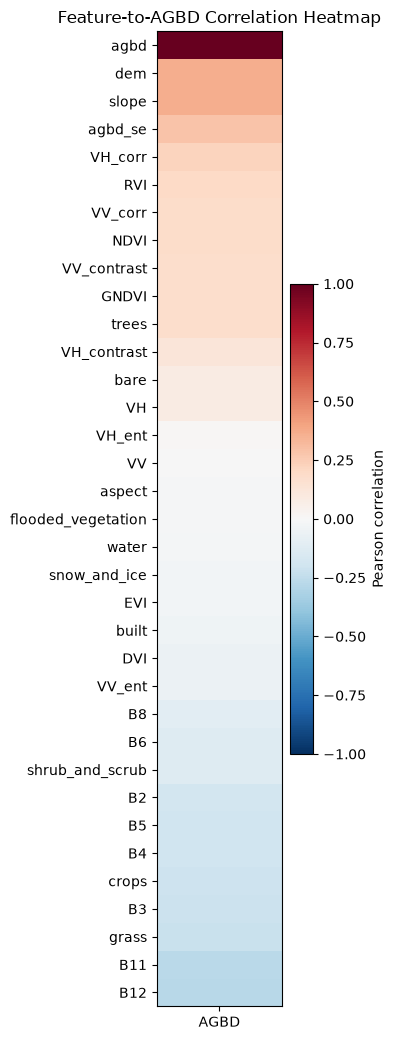

In [16]:
agbd_corr = numeric.corr()[["agbd"]].sort_values("agbd", ascending=False)

plt.figure(figsize=(4, max(5, len(agbd_corr) * 0.30)))
im = plt.imshow(agbd_corr.values, cmap=corr_cmap, vmin=-1, vmax=1,
                aspect="auto")
plt.colorbar(im, label="Pearson correlation")
plt.xticks([0], ["AGBD"])
plt.yticks(range(len(agbd_corr)), agbd_corr.index)
plt.title("Feature-to-AGBD Correlation Heatmap")
plt.tight_layout()
plt.show()


# **Data Preprocessing**

Tahap ini menyiapkan data fitur dan target, lalu membaginya menjadi data latih dan data uji.

- Menghapus kolom yang tidak dipakai (id, geometri, tanggal, `agbd_se`)
- Memisahkan fitur (`X`) dan target (`y` = `agbd`)
- Membagi data 80:20 untuk latih dan uji (`random_state=42`)
- Standarisasi fitur dinonaktifkan (di-comment) karena Random Forest tidak membutuhkannya

In [17]:
unused_cols = ['system:index', '.geo', 'year_month', 'agbd_se', 'grid_id', 'date']
df.drop(unused_cols, axis=1, inplace=True)

In [18]:
X = df.drop('agbd', axis=1)
y = df['agbd']

In [19]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Train:", X_train.shape)
print("Test :", X_test.shape)

Train: (2669, 33)
Test : (668, 33)


In [20]:
# scaler = StandardScaler()

# X_train_scaled = scaler.fit_transform(X_train)
# X_test_scaled = scaler.transform(X_test)

# **Modelling**

Tahap ini melatih model Random Forest Regressor untuk memprediksi AGBD.

- Mendefinisikan model
- Melatih model dengan `fit`
- Memprediksi data uji (`y_pred`)

In [22]:
rf = RandomForestRegressor(n_estimators=350, max_features=1.0, min_samples_leaf=2, max_samples=0.632, random_state=42)

rf.fit(X, y)

y_pred = rf.predict(X_test)

# **Evaluation**

Tahap ini mengukur akurasi prediksi dan menganalisis kontribusi tiap fitur.

- Menghitung R², RMSE, Relative RMSE, MSE, dan MAPE
- Scatter plot nilai aktual vs prediksi dengan garis prediksi sempurna
- Line plot nilai aktual dan prediksi per sampel
- Bar plot feature importance dari Random Forest

In [23]:
r2 = r2_score(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)
r_rmse = (rmse / y_test.mean()) * 100
mse = mean_squared_error(y_test, y_pred)
mape = mean_absolute_percentage_error(y_test, y_pred)

print(f"R2 Score: {r2}")
print(f"RMSE: {rmse}")
print(f"Relative RMSE: {r_rmse}")
print(f"MSE: {mse}")
print(f"MAPE: {mape}")

R2 Score: 0.8179182114719752
RMSE: 26.26546905300252
Relative RMSE: 20.036743059968924
MSE: 689.874864574233
MAPE: 0.24587898531933056


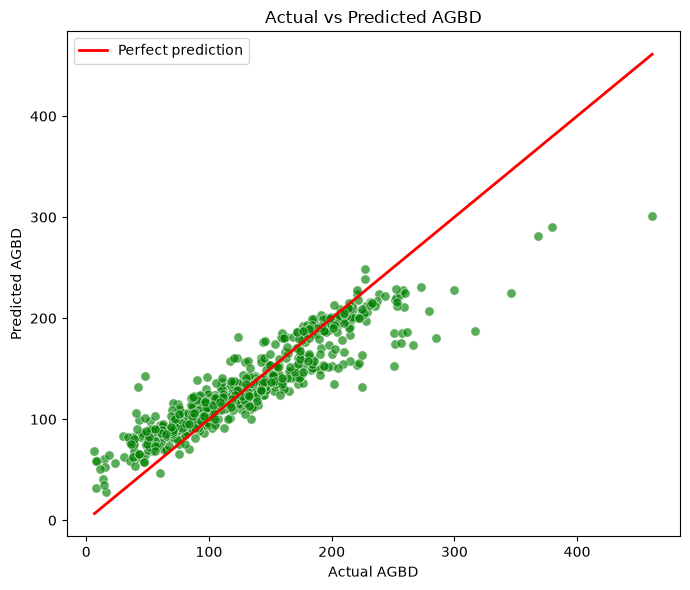

In [24]:
plot_df = pd.DataFrame({"Actual": y_test.values, "Predicted": y_pred})

plt.figure(figsize=(7, 6))
sns.scatterplot(data=plot_df, x="Actual", y="Predicted", color='green', s=45, alpha=0.65)
lims = [min(plot_df["Actual"].min(), plot_df["Predicted"].min()),
        max(plot_df["Actual"].max(), plot_df["Predicted"].max())]
plt.plot(lims, lims, linestyle="-", linewidth=2, color='red', label="Perfect prediction")
plt.xlabel("Actual AGBD")
plt.ylabel("Predicted AGBD")
plt.title("Actual vs Predicted AGBD")
plt.legend()
plt.tight_layout()
plt.show()

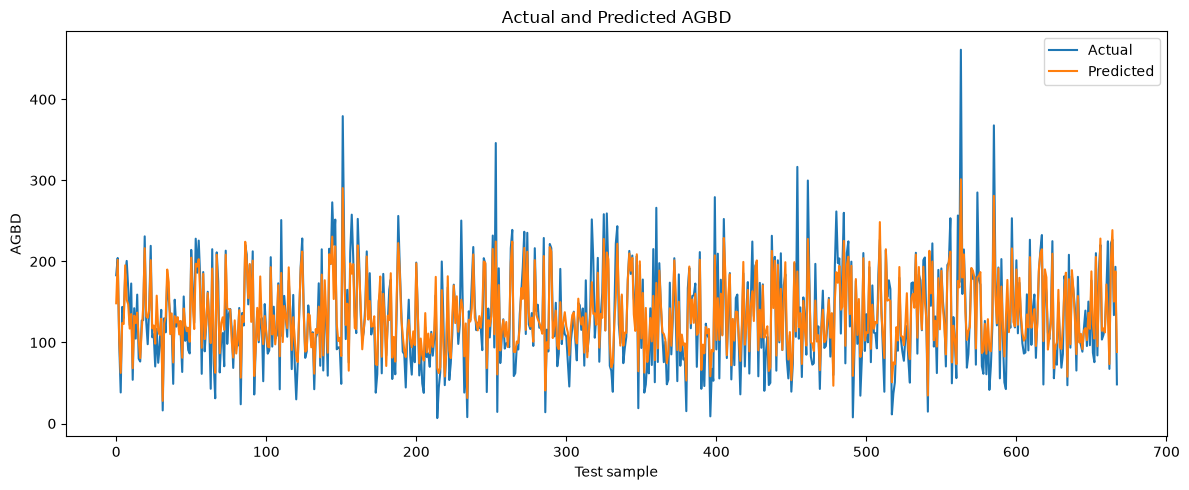

In [25]:
prediction_df = pd.DataFrame({"Actual": y_test.values, "Predicted": y_pred}).reset_index(drop=True)

plt.figure(figsize=(12, 5))
sns.lineplot(data=prediction_df, x=prediction_df.index, y="Actual", label="Actual", linewidth=1.5)
sns.lineplot(data=prediction_df, x=prediction_df.index, y="Predicted", label="Predicted", linewidth=1.5)
plt.xlabel("Test sample")
plt.ylabel("AGBD")
plt.title("Actual and Predicted AGBD")
plt.legend()
plt.tight_layout()
plt.show()

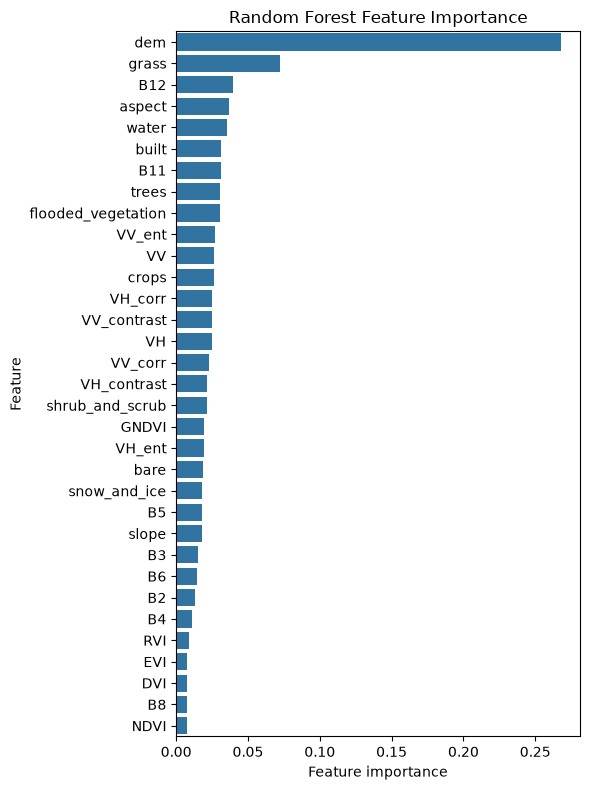

In [26]:
importance = (pd.Series(rf.feature_importances_, index=X_train.columns).sort_values(ascending=False))

plt.figure(figsize=(6, 8))
sns.barplot(x=importance.values, y=importance.index)
plt.xlabel("Feature importance")
plt.ylabel("Feature")
plt.title("Random Forest Feature Importance")
plt.tight_layout()
plt.show()

# **Save Models**

Tahap ini menyimpan model terlatih agar bisa dipakai kembali untuk inference.

- Menyimpan model dengan `pickle` ke `models/randomforest.pkl`
- Mencetak lokasi file hasil simpan

In [27]:
savepath = "models/randomforest.pkl"

# model_data = {
#     "model": rf,
#     "scaler": scaler,
#     "features": X.columns
# }

with open(savepath, "wb") as f:
    pkl.dump(rf, f)

print(f"Model berhasil disimpan: {savepath}")

Model berhasil disimpan: models/randomforest.pkl


In [ ]:
# Akses Model

# with open("rf_agbd.pkl", "rb") as f:
#     model_data = pickle.load(f)

# rf_loaded = model_data["model"]
# scaler_loaded = model_data["scaler"]
# features_loaded = model_data["features"]